# VQC Based on IQC:AIL

## Imports

In [1]:
import os

import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit,Parameter
from qiskit import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix

import pennylane as qml
from pennylane import numpy as pnp
import qutip
from toqito import state_props

import numpy as np
from scipy.linalg import expm as expMatrix
import math

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

import pandas as pd

from qiskit_qc import *

c:\Users\pichau\OneDrive - UFPE\Área de Trabalho\Bito\Exatas\MQ, CQ e IQ\TAAC1\Projeto-TAAC1\Proj2\qiskit_qc.py:624: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel(f'Factor of $\pi$')
c:\Users\pichau\OneDrive - UFPE\Área de Trabalho\Bito\Exatas\MQ, CQ e IQ\TAAC1\Projeto-TAAC1\Proj2\qiskit_qc.py:630: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_xlabel(f'Factor of $\pi$')
c:\Users\pichau\OneDrive - UFPE\Área de Trabalho\Bito\Exatas\MQ, CQ e IQ\TAAC1\Projeto-TAAC1\Proj2\qiskit_qc.py:636: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel(f'Factor of $\pi$')


## Parâmetros

In [2]:
RANDOM_SEED = 1
N_SAMPLES = 5000
N_PRINTINGS = 1
N_SHOTS=2048
SIMULATION_SAMPLES=5000

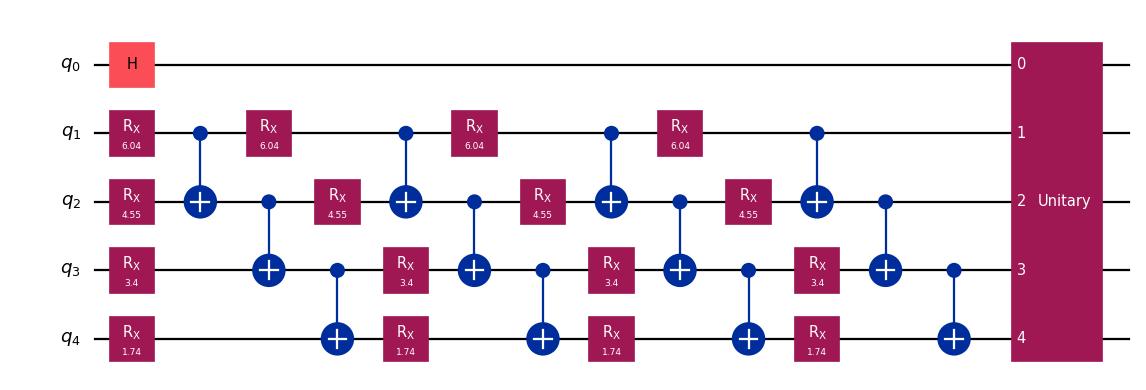

In [12]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]

N_layers=4
N_features=4
data = rng.random((1,N_features))
w=rng2.random((1,N_features))

X_new=np.array(data[0])
if N_layers==None:
    raise Exception("Number of Layers is required in Angle Embedding.")

N_QUBITS=(N_features+1) #Nqubits do circuito
QUBITS=[i for i in range(N_QUBITS)]
N_layers = N_layers

# Configura o circuito
qc = QuantumCircuit(N_QUBITS)

# Verifica se precisa ajustar sigmaE
sigmaE = np.diag(w)

# Adiciona a porta Hadamard no qubit alvo
qc.h(0)

# Adiciona as rotações RX e as CNOTs
for nl in range(N_layers):
    for i in range(len(X_new)):
        if i + 1 < N_QUBITS:
            qc.rx(X_new[i] * 2 * np.pi, i + 1)
            if i != 0:
                qc.cx(i, i + 1)

# Matriz sigmaQ
matriz_pauli_x = np.array([[0, 1], [1, 0]])  # Matriz de Pauli x
matriz_pauli_y = np.array([[0, -1j], [1j, 0]])  # Matriz de Pauli y
matriz_pauli_z = np.array([[1, 0], [0, -1]])  # Matriz de Pauli z
sigmaQ = matriz_pauli_x + matriz_pauli_y + matriz_pauli_z

# Calcula o operador unitário U
dim_circuit = 2 ** (N_QUBITS - 1)
dim_sigmaE = sigmaE.shape[0]
extended_sigmaE = np.kron(np.eye(dim_circuit // dim_sigmaE), sigmaE)
U = expMatrix(1j * np.kron(sigmaQ, extended_sigmaE))

# Adiciona o operador unitário ao circuito
fig,ax=plt.subplots(1,1,figsize=(12,4))
qc.unitary(U, QUBITS)
qc.draw('mpl',ax=ax)
fig.savefig('IQC_Angle_Example.svg')

## Circuito Teste (NÃO RODAR)

In [ ]:
N_features=4
N_QUBITS=(N_features+1) #Nqubits do circuito
QUBITS=[i for i in range(N_QUBITS)]
N_layers=4

qc = QuantumCircuit(N_QUBITS)
tx = np.random.rand(N_features)
tw = np.random.rand(N_features)

if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
    for k in range(2**(N_QUBITS-1) - N_features):
        tw=np.append(tw,0)
        tx=np.append(tx,0)
    sigmaE=np.diag(tw)
else:
    sigmaE=np.diag(tw)

qc.h(0) # We held Hadamard gate in the target system so we could make changes only in the environment system
for l in range(N_layers):
    for i in range(len(tx)):
        if i + 1 < N_QUBITS:  # Ensure index is within bounds
            qc.rx(tx[i] * 2 * np.pi, i + 1)
            if i != 0 :
                qc.cx(i, i + 1)

sigmaE = np.diag(tw)

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z


# Number of qubits
dim_circuit = 2**(N_QUBITS-1)

# Extend sigmaE to the full system
dim_sigmaE = sigmaE.shape[0]
extended_sigmaE = np.kron(np.eye(dim_circuit // dim_sigmaE), sigmaE)

# Calculate the unitary operator
U = expMatrix(1j * np.kron(sigmaQ, extended_sigmaE))

# Apply the gate to all qubits in the circuit
qc.unitary(U,QUBITS)
#display(qc.draw('mpl'))

In [ ]:

def haar_integral(num_qubits, samples):
    """
    Return the calculation of Haar Integral for a specified number of samples.
    """
    N = 2 ** num_qubits
    randunit_density = np.zeros((N, N), dtype=complex)

    zero_state = np.zeros(N, dtype=complex)
    zero_state[0] = 1

    for _ in range(samples):
        # Generate random unitary
        unitary = np.matrix(unitary_group.rvs(N))
        # Apply unitary to the zero state
        A = np.matmul(zero_state, unitary).reshape(-1, 1)
        # Accumulate density matrix
        randunit_density += np.kron(A, A.conj().T)

    # Normalize by number of samples
    randunit_density /= samples
    return randunit_density

# Função para calcular a integral do PQC
def pqc_integral_adapted(N_QUBITS, QUBITS, circuit_generator, samples,N_layers):
    """
    Calcula a integral de um PQC com parâmetros aleatórios.
    
    Args:
        num_qubits (int): Número de qubits no circuito.
        circuit_generator (function): Função que gera o circuito com parâmetros ajustáveis.
        samples (int): Número de amostras para calcular a integral.

    Returns:
        np.ndarray: Matriz densidade aproximada pelo circuito.
    """
    randunit_density = np.zeros((2 ** N_QUBITS, 2 ** N_QUBITS), dtype=complex)

    for _ in range(samples):
        # Gere os parâmetros aleatórios
        tx = np.random.uniform(0, 1, N_QUBITS - 1)  # Parâmetros para tx
        tw = np.random.uniform(0, 1, N_QUBITS - 1)  # Parâmetros para tw

        # Cria o circuito com os parâmetros fornecidos
        qc = circuit_generator(tx, tw, N_layers, N_QUBITS, QUBITS)

        # Simule o circuito para obter o vetor de estado
        statevector = Statevector.from_instruction(transpile(qc, Aer.get_backend("statevector_simulator")))

        # Reshape statevector para vetor coluna
        U = statevector.data.reshape(-1, 1)

        # Acumule a matriz densidade
        randunit_density += np.kron(U, U.conj().T)

    # Normalize pela quantidade de amostras
    return randunit_density / samples

# Função para gerar o circuito ajustável
def generate_circuit(tx, tw, N_layers, N_QUBITS, QUBITS):
    """
    Gera o circuito ajustável com base nos parâmetros fornecidos.
    
    Args:
        tx (np.ndarray): Parâmetros para as rotações RX.
        tw (np.ndarray): Parâmetros para construir sigmaE.

    Returns:
        QuantumCircuit: Circuito quântico ajustado.
    """
    N_features = len(tx)
    N_layers = N_layers

    # Configura o circuito
    qc = QuantumCircuit(N_QUBITS)

    # Verifica se precisa ajustar sigmaE
    if np.log2(N_features) % 2 != 0 and np.log2(N_features) != 1:
        for _ in range(2 ** (N_QUBITS - 1) - N_features):
            tw = np.append(tw, 0)
            tx = np.append(tx, 0)
        sigmaE = np.diag(tw)
    else:
        sigmaE = np.diag(tw)

    # Adiciona a porta Hadamard no qubit alvo
    qc.h(0)

    # Adiciona as rotações RX e as CNOTs
    for l in range(N_layers):
        for i in range(len(tx)):
            if i + 1 < N_QUBITS:
                qc.rx(tx[i] * 2 * np.pi, i + 1)
                if i != 0:
                    qc.cx(i, i + 1)

    # Matriz sigmaQ
    matriz_pauli_x = np.array([[0, 1], [1, 0]])  # Matriz de Pauli x
    matriz_pauli_y = np.array([[0, -1j], [1j, 0]])  # Matriz de Pauli y
    matriz_pauli_z = np.array([[1, 0], [0, -1]])  # Matriz de Pauli z
    sigmaQ = matriz_pauli_x + matriz_pauli_y + matriz_pauli_z

    # Calcula o operador unitário U
    dim_circuit = 2 ** (N_QUBITS - 1)
    dim_sigmaE = sigmaE.shape[0]
    extended_sigmaE = np.kron(np.eye(dim_circuit // dim_sigmaE), sigmaE)
    U = expMatrix(1j * np.kron(sigmaQ, extended_sigmaE))

    # Adiciona o operador unitário ao circuito
    qc.unitary(U, QUBITS)

    #qc.decompose().draw(output="mpl", style="clifford")
    tqc=transpile(qc, optimization_level=3, basis_gates=["u3", "cx"], seed_transpiler=1)

    gate_val = 0
    u3_dir = {}
    for i, instruction in enumerate(tqc.data):
        if instruction.operation.name == 'u3':
            u3_dir['u3_'+str(gate_val)] = {'qubit':instruction.qubits[0], 'params': instruction.operation.params}
            gate_val +=1
                
    u3_params = []
    for i in range(len(u3_dir)):
        u3_params.append(u3_dir[f'u3_{i}']['params'])

    # Mostrando o vetor de estado 
    sv = Statevector(qc)
    rho=np.array(DensityMatrix(sv))
    rho_cog = partial_trace(sv, QUBITS[1:])

    return qc


In [ ]:
N_features = 4
N_QUBITS = N_features + 1
QUBITS = [i for i in range(N_QUBITS)]
samples = 2048

np.linalg.norm(haar_integral(N_QUBITS, 2048) - pqc_integral_adapted(N_QUBITS, QUBITS, generate_circuit, samples, 4))

In [ ]:


tqc=transpile(qc, optimization_level=3, basis_gates=["u3", "cx"], seed_transpiler=1)
#display(tqc.draw('mpl'))

gate_val = 0
u3_dir = {}
for i, instruction in enumerate(tqc.data):
    if instruction.operation.name == 'u3':
        u3_dir['u3_'+str(gate_val)] = {'qubit':instruction.qubits[0], 'params': instruction.operation.params}
        gate_val +=1
        
print(u3_dir)
print()

gate_val = 0
u3_params = []
for i in range(len(u3_dir)):
    u3_params.append(u3_dir[f'u3_{i}']['params'])

sv=Statevector(qc)
rho=DensityMatrix(sv)


plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]
fig,ax=plt.subplots(1,3,figsize=(15,5))

ax[0].hist(array[:,0],label=labels[0],color=colors[0],edgecolor='black')
ax[0].set_xlabel(f'Factor of $\pi$')
ax[0].set_ylabel('Frequency')
ax[0].legend()
ax[0].grid(linestyle='dashed')

ax[1].hist(array[:,1],label=labels[1],color=colors[1],edgecolor='black')
ax[1].set_xlabel(f'Factor of $\pi$')
ax[1].set_ylabel('Frequency')
ax[1].legend()
ax[1].grid(linestyle='dashed')

ax[2].hist(array[:,2],label=labels[2],color=colors[2],edgecolor='black')
ax[2].set_xlabel(f'Factor of $\pi$')
ax[2].set_ylabel('Frequency')
ax[2].legend()
ax[2].grid(linestyle='dashed')
plt.show()

In [ ]:

tx = np.random.rand(N_features)
tw = np.random.rand(N_features)
sigmaE = np.diag(tx)*tw.T

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

# qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
qc.unitary(U,QUBITS)

display(qc.draw('mpl'))



tqc=transpile(qc, optimization_level=3, basis_gates=["u3", "cx"], seed_transpiler=1)
display(tqc.draw('mpl'))

gate_val = 0
u3_dir = {}
for i, instruction in enumerate(tqc.data):
    if instruction.operation.name == 'u3':
        u3_dir['u3_'+str(gate_val)] = {'qubit':instruction.qubits[0], 'params': instruction.operation.params}
        gate_val +=1
        
print(u3_dir)
print()

gate_val = 0
u3_params = []
for i in range(len(u3_dir)):
    u3_params.append(u3_dir[f'u3_{i}']['params'])

sv=Statevector(qc)
rho=DensityMatrix(sv)

array=np.array(u3_params)/np.pi
plt.plot(array)

plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'figure.autolayout': True})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]
fig,ax=plt.subplots(1,3,figsize=(15,5))

ax[0].hist(array[:,0],label=labels[0],color=colors[0],edgecolor='black')
ax[0].set_xlabel(f'Factor of $\pi$')
ax[0].set_ylabel('Frequency')
ax[0].legend()
ax[0].grid(linestyle='dashed')

ax[1].hist(array[:,1],label=labels[1],color=colors[1],edgecolor='black')
ax[1].set_xlabel(f'Factor of $\pi$')
ax[1].set_ylabel('Frequency')
ax[1].legend()
ax[1].grid(linestyle='dashed')

ax[2].hist(array[:,2],label=labels[2],color=colors[2],edgecolor='black')
ax[2].set_xlabel(f'Factor of $\pi$')
ax[2].set_ylabel('Frequency')
ax[2].legend()
ax[2].grid(linestyle='dashed')
plt.show()

## Função que gera o Quantum Circuit (NÃO RODAR)

In [ ]:
def blochvector(rho_cog,matriz_pauli_x,matriz_pauli_y,matriz_pauli_z):
    x_bloch = np.trace(matriz_pauli_x@rho_cog.data)
    y_bloch = np.trace(matriz_pauli_y@rho_cog.data)
    z_bloch = np.trace(matriz_pauli_z@rho_cog.data)
    return [x_bloch,y_bloch,z_bloch]
    
#Executar o circuito
def run_qasm_counts(qc, shots=N_SHOTS):
    qc.measure_all()
    qasm_simulator = Aer.get_backend("qasm_simulator")
    job = qasm_simulator.run(qc, shots=shots)
    result = job.result()
    return result.get_counts()

def get_negativity(rho, dim):
    """
        Returns the Negativity associated with densitiy matrix rho.
        See definition at: https://en.wikipedia.org/wiki/Negativity_(quantum_mechanics)
        See implementation at: https://toqito.readthedocs.io/en/latest/_autosummary/toqito.state_props.negativity.html
    """
    return state_props.negativity(rho, dim)

def cirq_iqc_ail(data,contador,w,counter,qubits, N_qubits,N_features,folder,printar_cirq=False):

    X_moons_new=list(data)
    if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
        for k in range(2**(N_qubits-1) - N_features):
            w=np.append(w,0)
            X_moons_new=np.append(X_moons_new,0)
        sigmaE=np.diag(w)
    else:
        sigmaE=np.diag(w)
    
    #Podíamos inicializar assim pra facilitar as contas
    '''x=np.random.rand(2**N_features)
    w=np.random.rand(2**N_features)'''

    # IQC:AIL

    qc = QuantumCircuit(N_qubits)
    qc.initialize(X_moons_new, range(1,N_qubits))# Inicializaçao do estado inicial. Poderia ser qualquer estado.
    qc.h(0)



    #Montando os sigmas

    matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
    matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
    matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

    sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

    # qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
    qc.unitary(U,qubits)
    if counter==0:
        qc.draw("mpl", filename=folder+f'/mpl_complete_U_NF{N_features}_IQC_AIL.svg')
    if printar_cirq==True:
        display(qc.draw('mpl')) #display(qc.draw("mpl", filename='./mpl_original.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    #qc.decompose().draw(output="mpl", style="clifford")
    tqc=transpile(qc, optimization_level=3, basis_gates=["u3", "cx"], seed_transpiler=1)

    gate_val = 0
    u3_dir = {}
    for i, instruction in enumerate(tqc.data):
        if instruction.operation.name == 'u3':
            u3_dir['u3_'+str(gate_val)] = {'qubit':instruction.qubits[0], 'params': instruction.operation.params}
            gate_val +=1
            
    if printar_cirq and dict(tqc.count_ops())['u3']<=50:
        print(u3_dir)
        print()

    
    u3_params = []
    for i in range(len(u3_dir)):
        u3_params.append(u3_dir[f'u3_{i}']['params'])

    if dict(tqc.count_ops())['u3']<=50 and contador==0:
        tqc.draw("mpl", filename=folder+f'/mpl_transpiled{contador}_NF{N_features}_IQC_AIL.svg')

    if printar_cirq==True and dict(tqc.count_ops())['u3']<=50:
        print(dict(tqc.count_ops()))
        display(tqc.draw('mpl')) #displat(qc.draw('mpl', filename='./mpl_transpile.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    # Mostrando o vetor de estado 
    sv = Statevector(qc)
    '''if contador%N_PRINTINGS==0:
        sv.draw("city", filename=folder+f'/state_vector_city{contador}_NF{N_features}.svg')
        sv.draw("bloch", filename=folder+f'/state_vector_bloch{contador}_NF{N_features}.svg')
        sv.draw("qsphere", filename=folder+f'/state_vector_qsphere{contador}_NF{N_features}.svg')
    if printar_cirq==True:
        display(sv.draw("latex"))
    '''
    rho=np.array(DensityMatrix(sv))
    rho_cog = partial_trace(sv, qubits[1:])
    if printar_cirq==True:
        print(rho_cog)
    
    return blochvector(rho_cog,matriz_pauli_x,matriz_pauli_y,matriz_pauli_z),u3_params, get_negativity(rho,[2, N_features])

def cirq_iqc(data,contador,w,counter, qubits, N_qubits,N_features,folder,printar_cirq=False):

    X_iris_new=list(data)
    if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
        for k in range(2**(N_qubits-1) - N_features):
            w=np.append(w,0)
            X_iris_new=np.append(X_iris_new,0)
        sigmaE=np.diag(X_iris_new)*w.T
    else:
        sigmaE=np.diag(X_iris_new)*w.T
    
    #Podíamos inicializar assim pra facilitar as contas
    '''x=np.random.rand(2**N_features)
    w=np.random.rand(2**N_features)'''

    # IQC

    qc = QuantumCircuit(N_qubits)

    qc.h(0)
    qc.h(range(1,N_qubits))



    #Montando os sigmas

    matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
    matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
    matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

    sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

    # qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
    qc.unitary(U,qubits)
    if counter==0:
        qc.draw("mpl", filename=folder+f'/mpl_complete_U_NF{N_features}_iqc.svg')
    if printar_cirq==True:
        display(qc.draw('mpl')) #display(qc.draw("mpl", filename='./mpl_original.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    #qc.decompose().draw(output="mpl", style="clifford")
    tqc=transpile(qc, optimization_level=3, basis_gates=["u3", "cx"], seed_transpiler=1)

    gate_val = 0
    u3_dir = {}
    for i, instruction in enumerate(tqc.data):
        if instruction.operation.name == 'u3':
            u3_dir['u3_'+str(gate_val)] = {'qubit':instruction.qubits[0], 'params': instruction.operation.params}
            gate_val +=1
            
    if printar_cirq and dict(tqc.count_ops())['u3']<=50:
        print(u3_dir)
        print()

    
    u3_params = []
    for i in range(len(u3_dir)):
        u3_params.append(u3_dir[f'u3_{i}']['params'])

    if dict(tqc.count_ops())['u3']<=50 and contador==0:
        tqc.draw("mpl", filename=folder+f'/mpl_transpiled{contador}_NF{N_features}_IQC.svg')

    if printar_cirq==True and dict(tqc.count_ops())['u3']<=50:
        print(dict(tqc.count_ops()))
        display(tqc.draw('mpl')) #displat(qc.draw('mpl', filename='./mpl_transpile.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos


    # Mostrando o vetor de estado 
    sv = Statevector(qc)
    '''if contador%N_PRINTINGS==0:
        sv.draw("city", filename=folder+f'/state_vector_city{contador}_iris_iqc.svg')
        sv.draw("bloch", filename=folder+f'/state_vector_bloch{contador}_iris_iqc.svg')
        sv.draw("qsphere", filename=folder+f'/state_vector_qsphere{contador}_iris_iqc.svg')
    if printar_cirq==True:
        display(sv.draw("latex"))
        
    counts = run_qasm_counts(qc)
    if contador%N_PRINTINGS==0:
        plot_histogram(counts,filename=folder+f'/histogram_plot_{contador}_iris_iqc.svg')'''
    rho=np.array(DensityMatrix(sv))
    rho_cog = partial_trace(sv, qubits[1:])
    if printar_cirq==True:
        print(rho_cog)

    
    return blochvector(rho_cog,matriz_pauli_x,matriz_pauli_y,matriz_pauli_z),u3_params, get_negativity(rho,[2, N_features])

## Esfera de Bloch do Circuito (NÃO RODAR)

In [ ]:
plt.rcParams.update({'font.size': 10})
labels=[r'$\theta$',r'$\phi$',r'$\lambda$']
colors = ['forestgreen','darkorange','dodgerblue','deeppink' ]

"""Definir X e w através de linspace e variar diretamente, sem construir a base de dados"""
def esfera_bloch_IQC_AIL(X,weights,norma,qubits, N_qubits,N_atributos, counter,folder,printar_esf=False):
    plt.rcParams.update({'figure.autolayout': False})
    point_states=[]
    u3_params=[]
    negativity=[]
    for k in range(len(X)):
        bloch,params,neg=cirq_iqc_ail(X[k],k,weights[k], counter, qubits, N_qubits, N_atributos,folder)
        point_states.append(bloch)
        u3_params.append(params)
        negativity.append(neg)
        counter+=1

    b = qutip.Bloch()
    b.point_default_color=['k']
    b.point_marker=['o']
    b.point_size=[10, 10, 10, 10]
    for k in range(len(point_states)):
        b.add_points(point_states[k])
    b.render()
    if printar_esf==True:
        b.show()

    bb = b.fig
    bb.savefig(fname=folder+f'/Bloch_geral_NF{N_features}_IQC_AIL_{norma}.svg')
    return u3_params,negativity
    

def esfera_bloch_IQC(X,weights,norma,qubits, N_qubits,N_atributos,counter,folder,printar_esf=False):
    point_states=[]
    u3_params=[]
    negativity=[]
    for k in range(len(X)):
        bloch,params,neg=cirq_iqc(X[k],k,weights[k], counter, qubits, N_qubits, N_atributos,folder)
        point_states.append(bloch)
        u3_params.append(params)
        negativity.append(neg)
        counter+=1


    b = qutip.Bloch()
    b.point_default_color=['k']
    b.point_marker=['o']
    b.point_size=[10, 10, 10, 10]
    for k in range(len(point_states)):
        b.add_points(point_states[k])
    b.render()
    if printar_esf==True:
        b.show()

    bb = b.fig
    bb.savefig(fname=folder+f'/Bloch_geral_NF{N_features}_IQC_{norma}.svg')
    return u3_params,negativity

## PLOTAR OS HISTOGRAMAS
Para cada parâmetro $\theta, \phi, \lambda$ das P portas dos circuitos de um N_FEATURES, plotar um histograma através das N_SAMPLES

### Available Models

In [3]:
av_qc()

Available models: 'IQC', 'IQC_AIL', 'IQCpQ', 'IQC_Angle', and 'IQCNDsE_xw'.


### IQC:AIL

In [4]:
MODEL='IQC_AIL'
NF=2
folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

u3_list,neg_list,express=statistical_qc(N_samples=N_SAMPLES, N_features=NF, simulation_samples=SIMULATION_SAMPLES, model=MODEL, folder=folder)

print(f"Expressibility of the {MODEL} Quantum Circuit with NF{NF}: {express}")
print()

plot_histogram_qc(u3_list,neg_list,N_features=NF,folder=folder,model=MODEL)

plot_negativity(neg_list,N_SAMPLES,N_features=NF,folder=folder,model=MODEL)
print()

NF=4
folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

u3_list,neg_list,express=statistical_qc(N_samples=N_SAMPLES, N_features=NF, simulation_samples=SIMULATION_SAMPLES, model=MODEL, folder=folder)

print(f"Expressibility of the {MODEL} Quantum Circuit with NF{NF}: {express}")
print()

plot_histogram_qc(u3_list,neg_list,N_features=NF,folder=folder,model=MODEL)

plot_negativity(neg_list,N_SAMPLES,N_features=NF,folder=folder,model=MODEL)


Expressibility of the IQC_AIL Quantum Circuit with NF2: 0.5089662616075638


Expressibility of the IQC_AIL Quantum Circuit with NF4: 0.5087244010334616



### IQC

In [5]:
MODEL='IQC'
NF=2
folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

u3_list,neg_list,express=statistical_qc(N_samples=N_SAMPLES, N_features=NF, simulation_samples=SIMULATION_SAMPLES, model=MODEL, folder=folder)

print(f"Expressibility of the {MODEL} Quantum Circuit with NF{NF}: {express}")
print()

plot_histogram_qc(u3_list,neg_list,N_features=NF,folder=folder,model=MODEL)

plot_negativity(neg_list,N_SAMPLES,N_features=NF,folder=folder,model=MODEL)
print()

NF=4
folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

u3_list,neg_list,express=statistical_qc(N_samples=N_SAMPLES, N_features=NF, simulation_samples=SIMULATION_SAMPLES, model=MODEL, folder=folder)

print(f"Expressibility of the {MODEL} Quantum Circuit with NF{NF}: {express}")
print()

plot_histogram_qc(u3_list,neg_list,N_features=NF,folder=folder,model=MODEL)

plot_negativity(neg_list,N_SAMPLES,N_features=NF,folder=folder,model=MODEL)


Expressibility of the IQC Quantum Circuit with NF2: 0.7455819432476353


Expressibility of the IQC Quantum Circuit with NF4: 0.804557187159185



In [6]:
lista=[]
for i in range(len(u3_list)):
    lista.append(len(u3_list[i]))
lista=np.unique_counts(lista)
lista

UniqueCountsResult(values=array([24, 25, 26, 30, 32]), counts=array([   3,   99, 1605, 3078,  215]))

### IQCpQ, N_qubits_tgt=2

In [7]:
MODEL='IQCpQ'
NF=2
NQ_TGT=2
folder=f'NF{NF}_'+MODEL+'_tgt2'
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

u3_list,neg_list,express=statistical_qc(N_samples=N_SAMPLES, N_features=NF, simulation_samples=SIMULATION_SAMPLES, model=MODEL, folder=folder,N_qubits_tgt=NQ_TGT)

print(f"Expressibility of the {MODEL} Quantum Circuit with NF{NF}: {express}")
print()

plot_histogram_qc(u3_list,neg_list,N_features=NF,folder=folder,model=MODEL)

plot_negativity(neg_list,N_SAMPLES,N_features=NF,folder=folder,model=MODEL)
print()

NF=4
folder=f'NF{NF}_'+MODEL+'_tgt2'
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

u3_list,neg_list,express=statistical_qc(N_samples=N_SAMPLES, N_features=NF, simulation_samples=SIMULATION_SAMPLES, model=MODEL, folder=folder,N_qubits_tgt=NQ_TGT)

print(f"Expressibility of the {MODEL} Quantum Circuit with NF{NF}: {express}")
print()

plot_histogram_qc(u3_list,neg_list,N_features=NF,folder=folder,model=MODEL)

plot_negativity(neg_list,N_SAMPLES,N_features=NF,folder=folder,model=MODEL)


c:\Users\pichau\OneDrive - UFPE\Área de Trabalho\Bito\Exatas\MQ, CQ e IQ\TAAC1\Projeto-TAAC1\Proj2\qiskit_qc.py:624: SyntaxWarning: invalid escape sequence '\p'
  ax[0].set_xlabel(f'Factor of $\pi$')
c:\Users\pichau\OneDrive - UFPE\Área de Trabalho\Bito\Exatas\MQ, CQ e IQ\TAAC1\Projeto-TAAC1\Proj2\qiskit_qc.py:630: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_xlabel(f'Factor of $\pi$')
c:\Users\pichau\OneDrive - UFPE\Área de Trabalho\Bito\Exatas\MQ, CQ e IQ\TAAC1\Projeto-TAAC1\Proj2\qiskit_qc.py:636: SyntaxWarning: invalid escape sequence '\p'
  ax[2].set_xlabel(f'Factor of $\pi$')


KeyboardInterrupt: 

### IQCpQ, N_qubits_tgt=4 (NÃO RODAR)

In [ ]:
MODEL='IQCpQ'
NF=2
NQ_TGT=4
folder=f'NF{NF}_'+MODEL+'_tgt4'
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

u3_list,neg_list,express=statistical_qc(N_samples=N_SAMPLES, N_features=NF, simulation_samples=SIMULATION_SAMPLES, model=MODEL, folder=folder,N_qubits_tgt=NQ_TGT)

print(f"Expressibility of the {MODEL} Quantum Circuit with NF{NF}: {express}")
print()

plot_histogram_qc(u3_list,neg_list,N_features=NF,folder=folder,model=MODEL)

plot_negativity(neg_list,N_SAMPLES,N_features=NF,folder=folder,model=MODEL)
print()

NF=4
folder=f'NF{NF}_'+MODEL+'_tgt4'
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

u3_list,neg_list,express=statistical_qc(N_samples=N_SAMPLES, N_features=NF, simulation_samples=SIMULATION_SAMPLES, model=MODEL, folder=folder,N_qubits_tgt=NQ_TGT)

print(f"Expressibility of the {MODEL} Quantum Circuit with NF{NF}: {express}")
print()

plot_histogram_qc(u3_list,neg_list,N_features=NF,folder=folder,model=MODEL)

plot_negativity(neg_list,N_SAMPLES,N_features=NF,folder=folder,model=MODEL)


### IQCNDsE_xw

In [ ]:
MODEL='IQCNDsE_xw'
NF=2
folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

u3_list,neg_list,express=statistical_qc(N_samples=N_SAMPLES, N_features=NF, simulation_samples=SIMULATION_SAMPLES, model=MODEL, folder=folder)

print(f"Expressibility of the {MODEL} Quantum Circuit with NF{NF}: {express}")
print()

plot_histogram_qc(u3_list,neg_list,N_features=NF,folder=folder,model=MODEL)

plot_negativity(neg_list,N_SAMPLES,N_features=NF,folder=folder,model=MODEL)
print()

NF=4
folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

u3_list,neg_list,express=statistical_qc(N_samples=N_SAMPLES, N_features=NF, simulation_samples=SIMULATION_SAMPLES, model=MODEL, folder=folder)

print(f"Expressibility of the {MODEL} Quantum Circuit with NF{NF}: {express}")
print()

plot_histogram_qc(u3_list,neg_list,N_features=NF,folder=folder,model=MODEL)

plot_negativity(neg_list,N_SAMPLES,N_features=NF,folder=folder,model=MODEL)


Expressibility of the IQCNDsE_xw Quantum Circuit with NF2: 0.4048318758331022


Expressibility of the IQCNDsE_xw Quantum Circuit with NF4: 0.41046375367382054



### IQC_Angle

In [4]:
MODEL='IQC_Angle'
NF=2
NL=4 # Number of Layers
folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

u3_list,neg_list,express=statistical_qc(N_samples=N_SAMPLES, N_features=NF, simulation_samples=SIMULATION_SAMPLES, model=MODEL, folder=folder, N_layers=NL)

print(f"Expressibility of the {MODEL} Quantum Circuit with NF{NF}: {express}")
print()

plot_histogram_qc(u3_list,neg_list,N_features=NF,folder=folder,model=MODEL)

plot_negativity(neg_list,N_SAMPLES,N_features=NF,folder=folder,model=MODEL)
print()

NF=4
NL=4 # Number of Layers
folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

u3_list,neg_list,express=statistical_qc(N_samples=N_SAMPLES, N_features=NF, simulation_samples=SIMULATION_SAMPLES, model=MODEL, folder=folder, N_layers=NL)

print(f"Expressibility of the {MODEL} Quantum Circuit with NF{NF}: {express}")
print()

plot_histogram_qc(u3_list,neg_list,N_features=NF,folder=folder,model=MODEL)

plot_negativity(neg_list,N_SAMPLES,N_features=NF,folder=folder,model=MODEL)


Expressibility of the IQC_Angle Quantum Circuit with NF2: 0.4736438777524313


Expressibility of the IQC_Angle Quantum Circuit with NF4: 0.39405619953323584



## Debugging

In [ ]:
import numpy as np

# Randomly initialize X and w
N_features = 4
X = np.random.randn(1, N_features)
w = np.random.randn(1, N_features)

# Ensure sigmaE is hermitian
sigmaE = X.T @ w + (X.T @ w).T

# Optionally, add a complex part if desired
# sigmaE += 1j * (X.T @ X - w.T @ w)

print("Matrix sigmaE:")
print(sigmaE)

# Check if sigmaE is Hermitian
print("\nIs sigmaE Hermitian?")
print(np.allclose(sigmaE, sigmaE.conj().T))


In [ ]:
import numpy as np

# Randomly initialize X and w
N_features = 4
X = np.random.randn(1, N_features)
w = np.random.randn(1, N_features)

# Ensure sigmaE is hermitian
sigmaE = X.T @ w + (X.T @ w).T+1j * (X.T @ X - w.T @ w)
# Add an optional complex part that maintains Hermiticity


print("Matrix sigmaE:")
print(sigmaE)

# Check if sigmaE is Hermitian
print("\nIs sigmaE Hermitian?")
print(np.allclose(sigmaE, sigmaE.conj().T))


In [ ]:
import numpy as np
from scipy.stats import unitary_group, kstest

def is_unitary(U):
    """Check if a matrix is unitary."""
    return np.allclose(U.conj().T @ U, np.eye(U.shape[0]))

def check_isotropy(U):
    """Check isotropy of rows and columns."""
    row_norms = np.linalg.norm(U, axis=1)
    col_norms = np.linalg.norm(U, axis=0)
    return np.allclose(row_norms, row_norms[0]) and np.allclose(col_norms, col_norms[0])

def analyze_distribution(U):
    """Check if entries follow Gaussian distribution."""
    real_parts = U.real.flatten()
    imag_parts = U.imag.flatten()
    _, real_pval = kstest(real_parts, 'norm')
    _, imag_pval = kstest(imag_parts, 'norm')
    return real_pval > 0.05 and imag_pval > 0.05

# Example matrix
N_features=2
N_qubits=math.ceil(np.log2(N_features)+1)
X=np.random.randn(1,N_features)
w=np.random.randn(1,N_features)
X_new=np.matrix(X)
if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
    for k in range(2**(N_qubits-1) - N_features):
        w=np.append(w,0)
        X_new=np.append(X_new,0)
    X_new=np.matrix(X_new)
    w=np.matrix(w)
    sigmaE=X_new.T@w
else:
    X_new=np.matrix(X_new)
    sigmaE=X_new.T@w

print(sigmaE)
#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))
# Check properties
if is_unitary(U):
    print("Matrix is unitary.")
    print("Isotropy:", check_isotropy(U))
    print("Gaussian distribution:", analyze_distribution(U))
else:
    print("Matrix is not unitary.")

import numpy as np

def gram_schmidt_columns(matrix):
    """
    Apply the Gram-Schmidt process to the columns of a given matrix to produce
    an orthonormal set of vectors.

    Parameters:
        matrix (numpy.ndarray): Input matrix of shape (m, n), where m >= n.

    Returns:
        numpy.ndarray: Matrix with orthonormal columns.
    """
    m, n = matrix.shape
    if m < n:
        raise ValueError("The number of rows must be greater than or equal to the number of columns.")

    # Create an empty matrix to store orthonormal vectors
    Q = np.zeros(2**N_qubits)
    Q = np.diag(Q)

    for i in range(n):
        # Start with the current column
        v = matrix[:][i]

        # Subtract projections of v onto previous vectors in Q
        for j in range(i):
            v -= np.dot(Q[:, j], matrix[:, i]) * Q[:, j]

        # Normalize the vector
        norm = np.linalg.norm(v)
        if norm == 0:
            raise ValueError("The input matrix has linearly dependent columns.")
        Q[:, i] = v / norm

    return Q

if is_unitary(gram_schmidt_columns(U)):
    print("Matrix is unitary.")
    print("Isotropy:", check_isotropy(U))
    print("Gaussian distribution:", analyze_distribution(U))
else:
    print("Matrix is not unitary.")

In [ ]:
N_features=32
N_qubits=math.ceil(np.log2(N_features)+1)
X_new=np.matrix(np.random.rand(N_features,1))
p=X_new*X_new.getH()

import numpy as np

def elementos_com_mais_uns(p):
    # Verifica se p é quadrada e a dimensão é uma potência de 2
    N = len(p)
    if not (N & (N - 1) == 0):  # Checa se N é uma potência de 2
        raise ValueError("A matriz não tem dimensão como potência de 2.")
    
    # Determina o número de bits para as strings binárias
    num_bits = int(np.log2(N))
    
    # Gera as strings binárias
    strings_binarias = [''.join(bits) for bits in itertools.product('01', repeat=num_bits)]
    
    # Filtra os índices em que há mais '1' do que '0'
    indices_1 = [i for i, s in enumerate(strings_binarias) if s.count('1') >= s.count('0')]
    indices_0 = [i for i, s in enumerate(strings_binarias) if s.count('1') < s.count('0')]
    
    # Acessa os elementos correspondentes de p
    elementos1 = [p[i, i] for i in indices_1]
    elementos0 = [p[i, i] for i in indices_0]
    
    return elementos1, indices_1, elementos0, indices_0

elementos1, indices_1, elementos0, indices_0 = elementos_com_mais_uns(p)
print(np.sum(elementos1))
print()
print(indices_1)
print()
print(np.sum(elementos0))
print()
print(indices_0)
print()

p1=0
p0=0
for i in indices_1:
    p1+=p[i,i]
for i in indices_0:
    p0+=p[i,i]

print(p1,p0)

In [ ]:
N_features=2
N_qubits=math.ceil(np.log2(N_features)+1)
X_new=np.random.rand(N_features)
U = np.matrix(unitary_group.rvs(2**N_qubits))
print(U)
print()
for i in range(len(U)):
    for j in range(len(U)):
        print(np.sqrt((U[i,j].real)**2+(U[i,j].real)**2))
print()
# Applying X to the diagonal of U
U[:N_features, :N_features] *= np.diag(X_new)  # Multiply the top-left diagonal block
U[N_features:, N_features:] *= np.diag(X_new)  # Multiply the bottom-right diagonal block

print(U)
print()
print(U*U.getH())